In [8]:
import datetime, calendar, glob, os, requests, pickle

import pickle as pkl
import geopandas as gpd
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from matplotlib import cm
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.transforms import ScaledTranslation

from skfda.exploratory.depth import ModifiedBandDepth, IntegratedDepth
from skfda import FDataGrid

from datetime import datetime, timedelta

from shapely.geometry import box
from shapely.ops import unary_union

from fda import _fDepth, _fQuantile
from utils import _get_hyper, _get_band_fraction, _KS

from fdu import functional_dynamic_update

plt.rcParams["legend.handlelength"] = 1
plt.rcParams["legend.handleheight"] = 1.125
plt.rcParams["font.family"] = "Avenir"

path_to_data = "/Users/Guille/Desktop/dynamic_update/data"
path_to_images = "/Users/Guille/Desktop/dynamic_update/images"
path_to_params = "/Users/Guille/Desktop/dynamic_update/params"
path_to_validation = "/Users/Guille/Desktop/dynamic_update/validation"
path_to_fDepth = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update/fDepth"

# Loading color palette
palette_ = pd.read_csv(path_to_data + "/palette.csv")
# Loading Texas map
TX_ = gpd.read_file(path_to_data + "/maps/TX/State.shp")

In [10]:
resource = 'wind'
method = 'fusion'
type = 'zone'
unbiased = True
T = 48

# Load dataset
with open(path_to_data + "/gridstatus/processed_ERCOT_wind_data_v4.pkl", "rb") as f:
    _DATA = pickle.load(f)

In [11]:
def _update_hyper_base(df1, df2, inits = {6: 1, 12: 1, 18: 1}):
    df = df1.copy()
    for interval in inits:
        for parameter in list(df2.columns[-5:]):
            idx_ = (df2['time'] == interval) & (df2['initialization'] == inits[interval])
            df.loc[parameter, interval] = np.around(df2.loc[idx_, parameter].values[0], 3)
    return df

file_name = f'{resource}_{method}_{type}-hyper-base.csv'
hyper_base = pd.read_csv(path_to_validation + f"/{file_name}")
hyper_base = hyper_base.set_index("parameter")
hyper_base.columns = hyper_base.columns.astype(int)
print(hyper_base)

file_name = f'{resource}_{method}_{type}-hyper-biased_sel.csv'
hyper_val = pd.read_csv(path_to_validation + f"/{resource}/{file_name}")

hyper_ = _update_hyper_base(hyper_base, hyper_val, 
                            inits = {6: 1, 12: 5, 18: 1})
print(hyper_)

file_name = f'{resource}_{method}_{type}-envelope-biased_sel.csv'
envelope_ = pd.read_csv(path_to_validation + f"/{resource}/{file_name}")
envelope_ = envelope_.set_index("time")
print(envelope_)

                        6           12          18
parameter                                         
clique_order      1.000000    1.000000    1.000000
forget_rate_f     0.500000    0.500000    0.500000
forget_rate_e     1.000000    1.000000    1.000000
lookup_rate      10.000000   10.000000   10.000000
length_scale_f    0.108202    0.035996    0.043199
length_scale_e    1.000000    1.000000    0.181275
trust_rate        0.100000    0.100000    0.100000
nu                3.000000    3.000000    3.000000
xi                0.650000    0.650000    0.650000
gamma            60.000000   60.000000   60.000000
kappa           175.000000  175.000000  175.000000
p_fusion          1.000000    1.000000    1.000000
                     6        12       18
parameter                                
clique_order      1.000    0.000    0.000
forget_rate_f     0.262    0.084    0.109
forget_rate_e     1.000    1.000    1.000
lookup_rate      10.000   10.000   10.000
length_scale_f    0.002    0.002  

In [12]:
# file_name = f'{resource}_{method}_{type}-hyper-base.csv'
# hyper_ = pd.read_csv(path_to_validation + f"/{file_name}")
# hyper_ = hyper_.set_index("parameter")
# hyper_.columns = hyper_.columns.astype(int)
# print(hyper_)

# file_name = f'{resource}_{method}_{type}-hyper-biased_sel.csv'
# hyper_ = pd.read_csv(path_to_validation + f"/{resource}/{file_name}")
# hyper_ = envelope_.set_index("time")
# print(envelope_)

# file_name = f'{resource}_{method}_{type}-envelope-biased_sel.csv'
# envelope_ = pd.read_csv(path_to_validation + f"/{resource}/{file_name}")
# envelope_ = envelope_.set_index("time")
# print(envelope_)

In [98]:
# load dataset
def _load_dataset(_dataset, region, N_test_samples, 
                 unbiased = False):
    #print(region, N_test_samples)

    dt_tr_ = _dataset[region]['datetime_actuals'][:-N_test_samples, ...]
    dt_ts_ = _dataset[region]['datetime_actuals'][-N_test_samples:, ...]
    #print(dt_tr_.shape, dt_ts_.shape)
    
    d_tr_ = _dataset[region]['datetime_actuals'][:-N_test_samples, 0, 0, 24]
    d_ts_ = _dataset[region]['datetime_actuals'][-N_test_samples:, 0, 0, 24]
    d_tr_ = pd.to_datetime(d_tr_).dayofyear.to_numpy()
    d_ts_ = pd.to_datetime(d_ts_).dayofyear.to_numpy()
    #print(d_tr_.shape, d_ts_.shape)

    datetime_tr_ = _dataset[region]['datetime_actuals'][:-N_test_samples, ...]
    datetime_ts_ = _dataset[region]['datetime_actuals'][-N_test_samples:, ...]
    #print(datetime_tr_.shape, datetime_ts_.shape)

    F_tr_ = _dataset[region]['actuals'][:-N_test_samples, ...] 
    F_ts_ = _dataset[region]['actuals'][-N_test_samples:, ...]
    #print(F_tr_.shape, F_ts_.shape)

    if unbiased:
        E_tr_ = _dataset[region]['unbiased_forecasts'][:-N_test_samples, ...] 
        E_ts_ = _dataset[region]['unbiased_forecasts'][-N_test_samples:, ...]
    else:
        E_tr_ = _dataset[region]['forecasts'][:-N_test_samples, ...] 
        E_ts_ = _dataset[region]['forecasts'][-N_test_samples:, ...]
    #print(E_tr_.shape, E_ts_.shape)

    X_tr_ = _dataset[region]['neighbors'][:-N_test_samples, ...]
    X_ts_ = _dataset[region]['neighbors'][-N_test_samples:, ...]
    #print(X_tr_.shape, X_ts_.shape)

    # Formating 
    idx_  = X_ts_[..., 1] == 0.
    F_ts_ = F_ts_[idx_, ...]
    E_ts_ = E_ts_[idx_, ...]
    X_ts_ = X_ts_[idx_, ...]
    datetime_ts_ = datetime_ts_[idx_, ...]
    #print(F_ts_.shape, E_ts_.shape, d_ts_.shape, X_ts_.shape, datetime_ts_.shape)

    F_tr_ = np.concatenate([F_tr_[:, i, ...] for i in range(F_tr_.shape[1])], axis = 0)
    E_tr_ = np.concatenate([E_tr_[:, i, ...] for i in range(E_tr_.shape[1])], axis = 0)
    d_tr_ = np.concatenate([d_tr_ for i in range(X_tr_.shape[1])], axis = 0)
    X_tr_ = np.concatenate([X_tr_[:, i, ...] for i in range(X_tr_.shape[1])], axis = 0)
    datetime_tr_ = np.concatenate([datetime_tr_[:, i, ...] for i in range(datetime_tr_.shape[1])], axis = 0)
    #print(E_tr_.shape, E_tr_.shape, d_tr_.shape, X_tr_.shape, datetime_tr_.shape)

    dt_ = np.linspace(0, dt_tr_.shape[-1] - 1, dt_ts_.shape[-1])*12*5
    #print(dt_.shape)

    return F_tr_, F_ts_, E_tr_, E_ts_, d_tr_, d_ts_, datetime_tr_, datetime_ts_, X_tr_, X_ts_, dt_

zone = 2
day = 150
interval = 12
print(zone, interval, day)

regions_ = list(_DATA['Graph'].keys())
region = regions_[zone]

(F_tr_, F_ts_, 
 E_tr_, E_ts_, 
 d_tr_, d_ts_, 
 t_tr_, t_ts_, 
 X_tr_, X_ts_, dt_) = _load_dataset(_DATA['Dataset'], region,
                                    N_test_samples = 360,
                                    unbiased = unbiased)

dt_p_ = dt_ + 60
dx_ = np.array([(t_ts + timedelta(minutes=0)).strftime('%b %-d %-I%p').replace('AM', 'am').replace('PM', 'pm') 
                for t_ts in t_ts_[day, interval]])

2 12 150


Panhandle May 28 7am
(24,) (48,) (48,) (72,)
(498,) (186,) (130,)


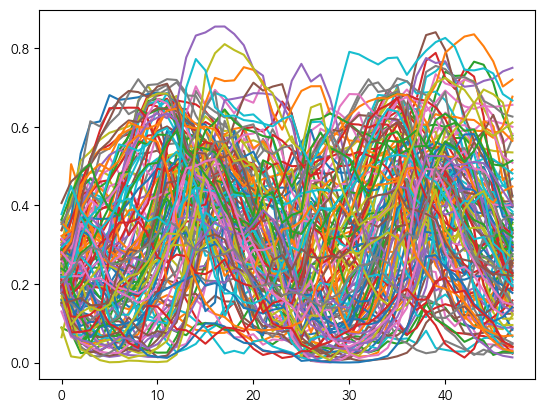

In [99]:
_distances = {'temporal': 'seasonal_equinox', 'spatial': 'graph'}
_fdu = functional_dynamic_update(_distances, region, dx_[24])
print(_fdu.name, _fdu.date)

F_tr_p_ = F_tr_[:, interval, :]
E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, interval, :]], axis = 1)
#print(F_tr_p_.shape, E_tr_p_.shape)

_fdu.fit(F_tr_p_, E_tr_p_, dt_, 
         X_ = X_tr_, 
         t_ = d_tr_, 
         n_samples_per_hour = 1)

f_ = F_ts_[day, interval, :24]
f_hat_ = F_ts_[day, interval, 24:]
e_ = E_ts_[day, interval, ...]
e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)
print(f_.shape, f_hat_.shape, e_.shape, e_p_.shape)
  
# M_ = _fdu.predict(f_, e_p_, X_ts_[day], d_ts_[day],
#                   clique_order = _get_hyper(hyper_, 'clique_order', interval),
#                   forget_rate_f = _get_hyper(hyper_, 'forget_rate_f', interval)*2,
#                   forget_rate_e = _get_hyper(hyper_, 'forget_rate_e', interval)*2,
#                   length_scale_f = _get_hyper(hyper_, 'length_scale_f', interval)*10,
#                   length_scale_e = _get_hyper(hyper_, 'length_scale_e', interval),
#                   lookup_rate =  _get_hyper(hyper_, 'lookup_rate', interval),
#                   trust_rate = _get_hyper(hyper_, 'trust_rate', interval)*9,
#                   nu = _get_hyper(hyper_, 'nu', interval),
#                   xi = _get_hyper(hyper_, 'xi', interval),
#                   gamma = _get_hyper(hyper_, 'gamma', interval),
#                   kappa = _get_hyper(hyper_, 'kappa', interval)/2.,
#                   p_fusion = _get_hyper(hyper_, 'p_fusion', interval))
#0	0.0625	96	0.05	2	0.95	90	200
#0.478251851	96	0.22404516	2	0.05	90	130
M_ = _fdu.predict(f_, e_p_, X_ts_[day], d_ts_[day],
                  clique_order = 0,
                  forget_rate_f = 0.478251851,
                  forget_rate_e = 1.,
                  length_scale_f = 0.0025,
                  length_scale_e = 0.1,
                  lookup_rate = 96,
                  trust_rate = 0.22404516,
                  nu = 2,
                  xi = 0.05,
                  gamma = 90,
                  kappa = 130,
                  p_fusion = 1)

file_name = f"{resource}-{region}-{day}-{interval}-zone"

print(_fdu.idx_neighbors_.shape, _fdu.idx_temporal_.shape, _fdu.idx_spatial_.shape)

plt.figure()
plt.plot(M_.T)
plt.show()

In [100]:
# def _plot_dynamic_update(_ax, F_curves_, f_hat_, dx_, dt_,
#                          legend = False,
#                          colorbar = True,
#                          label = r"$\bar{f} (s)$",
#                          range_ = [0, 287]):

#     _cmap = sns.color_palette("rocket_r", as_cmap=True)
#     _norm = plt.Normalize(0., len(F_curves_))

#     _ax.plot([], [], 
#              lw = 0.75,
#              label = label if legend else None, 
#              c = "k")
    
#     _ax.plot(dt_, 100 * f_hat_, 
#              c = palette_.loc[0, "ibm"], 
#              zorder = 10, 
#              label = "CF (actual)" if legend else None, 
#              lw = 2, 
#              clip_on = False)

#     # _ax.plot(dt_, 100 * e_, 
#     #          lw = 2, 
#     #          zorder = 9, 
#     #          label = "CF (forecast)" if legend else None, 
#     #          c = "k", 
#     #          clip_on = False)
    
#     for i in range(len(F_curves_)):
#         focal_curve_ = F_curves_[i]

#         _ax.plot(dt_[:focal_curve_.shape[0]], 100 * focal_curve_, 
#                  c = _cmap(_norm(i)), 
#                  lw = .75, 
#                  zorder = 8)
#         dt_ += 60
    
#     # _ax.set_xticks(dt_[24::24], dx_[24::24], rotation=0)
#     _ax.set_ylim(0, 100)
#     # _ax.set_xlim(dt_[0], dt_[-1])
#     _ax.set_ylabel("Capacity Factor (%)", size=14)

#     _ax.tick_params(axis="both", 
#                     labelsize=12)

#     if colorbar: 
#         cbar = _fig.colorbar(cm.ScalarMappable(_norm, _cmap),
#                              cax=_ax.inset_axes([60, 80, 150, 5], transform=_ax.transData),
#                              orientation="horizontal")
    
#         cbar.set_ticks([0, len(F_curves_)], 
#                        labels=["1:00", "23:00"], 
#                        size=12)
        
#         #cbar.ax.tick_params(length=0)
        
#         cbar.ax.set_title("Event (update)", 
#                           rotation=0, 
#                           size=12)

# _fig, _ax = plt.subplots(figsize = (7.5, 2.25), 
#                          constrained_layout = True)

# f_hat_ = F_ts_[day + 1, 0, :]
# print(dt_.shape, f_.shape, f_hat_.shape)
# _plot_dynamic_update(_ax, F_curves_, f_hat_, dx_, dt_,
#                      label = 'Focal curves',
#                      legend = True,
#                      colorbar = False)

# _ax.legend(loc=(0.2, 0.0125),
#            frameon=False, 
#            fontsize=12, 
#            ncol=3)

# # plt.savefig(path_to_images + f"/dynamic_update-focal_curve-{file_name}.pdf", 
# #             bbox_inches="tight")

# plt.show()

In [101]:
# # Define exponential growth function
# def _exponential_growth(t, growth_rate, n_samples_per_hour):
#     t = int(t)
#     tau_ = np.linspace(t - 1, 0, t)/n_samples_per_hour
#     return np.exp(np.log(0.5)*tau_/growth_rate)

# # Define exponential decay function
# def _exponential_decay(S, decay_rate, n_samples_per_hour):
#     S = int(S)
#     s_ = np.linspace(0, S - 1, S)/n_samples_per_hour
#     return np.exp(np.log(0.5)*s_/decay_rate)   


# # Linear Inverse Exponential (LIE) function
# def _linear_inverse_exponential(x_, T, nu, trust_rate, n_samples_per_hour,
#                                 k=2.5,
#                                 alpha=1.0):
#     """
#     x_ is in minutes.
#     T is the number of samples.
#     nu is in hours.
#     n_samples_per_hour = 1 for hourly data, 12 for 5-minute data.
#     """

#     minutes_per_sample = 60 / n_samples_per_hour
#     T_minutes = T * minutes_per_sample
#     nu_minutes = nu * 60

#     x_ = x_ - T_minutes + nu_minutes
#     x_ = k * x_ / (nu_minutes - minutes_per_sample)

#     y_ = np.where(x_ > 0, -x_, -alpha * (np.exp(x_) - 1))
#     y_ = (y_ + k) / (k + alpha)

#     return trust_rate * y_

# n_samples_per_hour = 1
# interval = 12
# T = 48
# dt_ = np.array([t * 5 * 12 for t in range(T)]) #+ 5 * 12

# n_samples_per_hour = 12
# interval = 144
# T = 288
# dt_ = np.array([t * 5 for t in range(T)])


# forget_rate_e = 1
# lookup_rate_e = 2
# trust_rate_e = 0.25
# nu = 6
# print(dt_.shape)

# psi_minus_ = _exponential_growth(interval, forget_rate_e, n_samples_per_hour)
# psi_plus_ = _exponential_decay(T - interval, lookup_rate_e, n_samples_per_hour)
# eta_ = _linear_inverse_exponential(dt_[:T][::-1], T, nu, trust_rate_e, n_samples_per_hour)
# psi_ = np.concatenate([psi_minus_, psi_plus_], axis = 0)
# print(eta_)
# plt.figure()
# plt.plot(psi_)
# plt.plot(eta_)
# plt.show()

[0.         0.16003226 0.21879066 0.22361384 0.22400976 0.22404225
 0.22404492 0.22404514 0.22404516 0.22404516 0.22404516 0.22404516
 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516
 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516
 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516
 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516
 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516
 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516 0.22404516]
(24,) (48,)
(72,) 24
(48,) (24,) (48,)


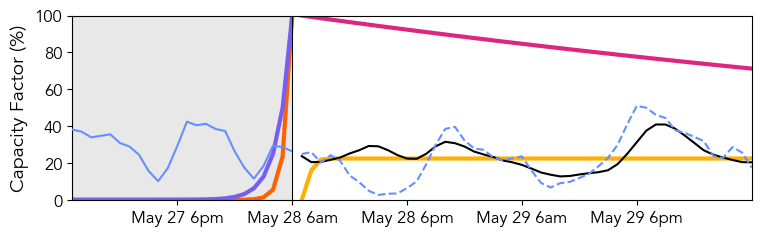

In [102]:
def _plot_forecast_parameters(_ax, phi_, psi_, eta_, f_, f_hat_, e_, dx_, dt_, interval,
                              n = 720,
                              labels_1 = False,
                              labels_2 = False):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]
    print(f_.shape, f_hat_.shape)
    print(dt_.shape, interval)
    print(s_.shape, tau_.shape, eta_.shape)
    _ax.plot(tau_, 100 * f_, 
             c=palette_.loc[0, "ibm"], 
             label="CF (actual)" if labels_1 else None, 
             lw=1.5, 
             zorder=5)

    _ax.plot(s_, 100 * f_hat_, 
             c=palette_.loc[0, "ibm"], 
             lw=1.5, 
             ls="--", 
             zorder=5)

    _ax.plot(dt_, 100 * e_, 
             lw=1.5, 
             label="CF (forecast)" if labels_1 else None, 
             c="k", 
             zorder=4)

    _ax.plot(tau_, 100 * phi_,
             c=palette_.loc[3, "ibm"],
             lw=3,
             label=r"$\phi_{\varepsilon_f} (\tau)$" if labels_2 else None,
             zorder=2)
    
    _ax.plot(tau_, 100. * psi_[:interval],
             c=palette_.loc[1, "ibm"],
             lw=3,
             label=r"$\phi_{\varepsilon_e} (\tau)$" if labels_2 else None,
             zorder=2)

    _ax.plot(s_, 100. * psi_[interval:],
             c=palette_.loc[2, "ibm"],
             lw=3,
             label=r"$\psi_{\eta} (s)$" if labels_2 else None,
             zorder=2)

    _ax.plot(s_, 100 * eta_,
             c=palette_.loc[4, "ibm"],
             lw=3,
             label=r"$\sigma_{\alpha} (s)$" if labels_2 else None,
             zorder=2)

    _ax.axvline(dt_[interval - 1], 
                color="k", 
                lw=0.75, 
                label="Event (update)" if labels_1 else None, 
                zorder=6)
    
    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    idx_ = (dt_ % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt_[idx_], dx_[idx_], rotation=0)
    
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    _ax.tick_params(axis="both", labelsize=12)
    _ax.set_ylim(0.0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])

fig, _ax = plt.subplots(figsize = (7.5, 2.25), 
                        constrained_layout = True)

e_p_[:24] = np.nan
print(_fdu.eta_)
_plot_forecast_parameters(_ax, _fdu.phi_, _fdu.psi_, _fdu.eta_, 
                          f_, f_hat_, e_p_, dx_, dt_p_, 24,
                          labels_1 = True,
                          labels_2 = False)

# _ax.legend(frameon=False, 
#            ncol=2, 
#            loc=(0.0125,0.7), 
#            #loc=(0.362,0.625), 
#            fontsize=12)
        
plt.show()

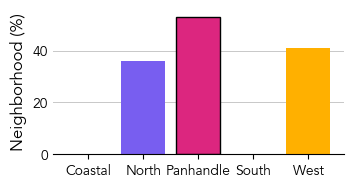

In [103]:
def _plot_neighborhood(ax, X_, regions_, idx_, region):
    
    # Data
    y_ = np.array(regions_)
    x_ = np.zeros((len(y_),))

    colors_ = [palette_['ibm'].iloc[i] for i in range(len(y_))]
    lws_ = np.zeros((len(y_),))
    lws_[y_ == region] = 1

    for edge in np.unique(X_[idx_, 0].astype(int)):
        x_[edge] = (X_[idx_, 0] == edge).sum()

    #x_ = 100*x_/x_.sum()
    
    ax.bar(y_, x_, color = colors_, ec = 'k', lw = lws_)
    
    # --- Style: keep only bottom axis ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Remove y-axis ticks (optional, for cleaner look)
    ax.yaxis.set_ticks_position('none')
    # Keep only bottom ticks
    ax.xaxis.set_ticks_position('bottom')
    
    # --- Horizontal auxiliary lines ---
    ax.yaxis.grid(True,linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)  # grid behind bars
    # Optional: light y ticks without spine
    ax.tick_params(axis='y', length=0, labelsize=10)
    ax.tick_params(axis='x', labelsize=10)

    ax.set_ylabel("Neighborhood (%)", fontsize = 12)
    #ax.set_ylim(0, 100)

# Plot
fig, _ax = plt.subplots(figsize = (3.75, 1.875))

_plot_neighborhood(_ax, X_tr_, regions_, _fdu.idx_spatial_, region)

plt.savefig(path_to_images + f"/region_neighbors-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

4 26 31
[3 4 5 6]
[36 55 57 38]


 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_53186/3314070813.py:95: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_53186/3314070813.py:95: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning:constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.


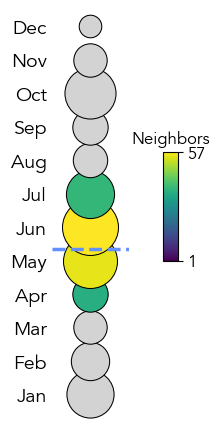

In [104]:
def _scenarios_frequency_dates(_fig, _ax, 
                               idx_neighbors_, 
                               idx_temporal_, t_tr_, t_ts, 
                               scale = 2.5,
                               colorbar = True):
    
    _date = pd.to_datetime(t_ts)
    m_a = _date.timetuple().tm_mon - 1
    day = _date.timetuple().tm_mday - 1
    _, n_days = calendar.monthrange(_date.year, m_a + 1)
    print(m_a, day, n_days)

    m_tr_ = pd.to_datetime(t_tr_).month.values - 1
    
    month_name_ = ["Jan", "Feb", "Mar", "Apr",
                   "May", "Jun", "Jul", "Aug",
                   "Sep", "Oct", "Nov", "Dec"]
    
    months_, counts_ = np.unique(m_tr_[idx_neighbors_], return_counts=True)

    counts_1_ = np.zeros(12)
    for month, count in zip(months_, counts_):
        counts_1_[month] = count
    
    months_, counts_ = np.unique(m_tr_[idx_temporal_], return_counts=True)
    print(months_)
    print(counts_)

    counts_2_ = np.zeros(12)
    for month, count in zip(months_, counts_):
        counts_2_[month] = count

    months_ = np.arange(12, dtype = int)
    jitter_strength = 0.5
    x_ = 0. + np.random.normal(0, jitter_strength, size=months_.shape[0])*0.

    counts_2_p_ = counts_2_.copy()
    counts_2_p_[counts_2_ == 0] = np.nan

    _cmap = sns.color_palette("viridis", as_cmap=True)
    _cmap.set_bad(color= 'lightgray')  # RGBA: transparent
    _norm = plt.Normalize(1, counts_2_.max())

    # Plot bubbles
    for i in range(x_.shape[0]):    
        _ax.scatter(x_[i], months_[i], 
                    s=scale*counts_1_[i]**2,
                    color=_cmap(_norm(counts_2_p_[i])),
                    ec='k',
                    vmin=1, 
                    vmax=counts_2_.max(),
                    lw=0.75, 
                    clip_on = False,
                    zorder = 6)

    _ax.set_xlim(-5, 5)
    _ax.set_xticks(x_, []*len(x_))
    _ax.set_yticks(np.arange(len(month_name_), dtype=int), month_name_, size=14)
    
    _ax.tick_params(axis='y', length=0)
    _ax.tick_params(axis='x', length=0)

    _ax.axhline(m_a + day/n_days - 0.5, 
                color=palette_.loc[0, "ibm"], 
                ls = '--',
                lw=2.5, 
                zorder=6)
    
    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         cax=_ax.inset_axes([7.5, 4, 1.5, 3.25], transform = _ax.transData))

    cbar.set_ticks([0, 1], 
                   labels = [1, int(counts_2_.max())], 
                   fontsize=12)
        
    cbar.ax.set_title("Neighbors", 
                      rotation = 0, 
                      fontsize = 12)
    
    _ax.set_xlim(-4, 4)

    sns.despine(left=True, 
                bottom=True) 

fig, _ax = plt.subplots(figsize = (1, 5), constrained_layout = True)

_scenarios_frequency_dates(fig, _ax,
                           _fdu.idx_neighbors_, 
                           _fdu.idx_temporal_, 
                           t_tr_[:, interval, 12], 
                           t_ts_[day, interval, 12], 
                           scale = .5,
                           colorbar = True)

plt.savefig(path_to_images + f"/temporal_neiboring-{file_name}.pdf", 
            bbox_inches="tight")

plt.show()

(24,) (48,) (24,) (48,)


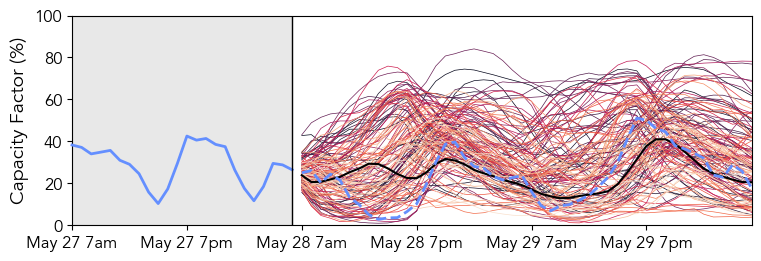

In [105]:
def _plot_forecasts(_ax, 
                    E_tr_, 
                    w_, 
                    idx_, 
                    f_, 
                    f_hat_, 
                    e_, 
                    dx_, 
                    dt_, 
                    interval, 
                    n = 720,
                    legend = False):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]

    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    idx_ = idx_[np.argsort(w_[idx_])]

    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0, 1)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$E_{\star} \left([\tau, s]\right)$", 
             c="k")
    print(f_.shape, f_hat_.shape, tau_.shape, s_.shape)
    _ax.plot(tau_, 100. * f_,
             c=palette_.loc[0, "ibm"],
             clip_on=False,
             zorder=10,
             #label="CF (ac)",
             lw=2)

    _ax.plot(s_, 100. * f_hat_,
             c=palette_.loc[0, "ibm"],
             clip_on=False,
             zorder=10,
             lw=2,
             ls="--")

    _ax.plot(dt_, 100. * e_, 
             clip_on=False, 
             lw=1.5, 
             zorder=9, 
             #label="CF (fc)", 
             c="k")

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_, 100 * E_tr_[i, :], 
                 #c=_cmap(_norm(z_[i])), 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 lw=.5, 
                 zorder=8)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.axvline(dt_[interval - 1], 
                color="k", 
                lw=1.0, 
                zorder=11)

    idx_ = (dt_ % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt_[idx_], dx_[idx_], rotation=0)

    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

e_p_[:24] = np.nan
E_tr_p_[:, :24] = np.nan

_plot_forecasts(_ax, 
                E_tr_p_, 
                _fdu.w_, 
                _fdu.idx_spatial_, 
                f_, 
                f_hat_, 
                e_p_, 
                dx_, 
                dt_, 
                24)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

# plt.savefig(path_to_images + f"/dayahead_neighbors-{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

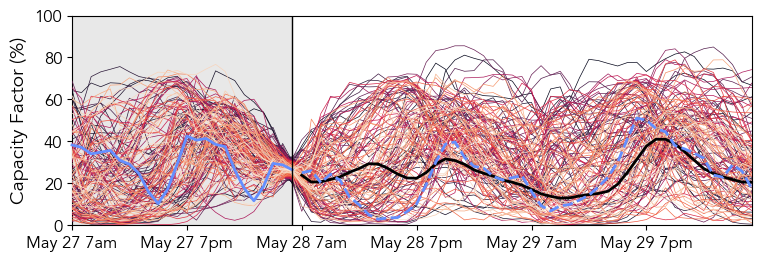

In [106]:
def _plot_neighbors(_ax, 
                    F_tr_, 
                    w_, 
                    idx_, 
                    f_, 
                    f_hat_, 
                    e_, 
                    dx_, 
                    dt_, 
                    interval,
                    n = 720):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]

    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    idx_ = idx_[np.argsort(w_[idx_])]

    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1.)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$\mathcal{F}_{\star} \left([\tau, s] \right)$", 
             c="k")
    
    _ax.plot(tau_, 100 * f_, 
             c=palette_.loc[0, "ibm"], 
             zorder=10, 
             #label="CF (ac)", 
             lw=2, 
             clip_on = False)

    _ax.plot(s_, 100 * f_hat_, 
             c=palette_.loc[0, "ibm"], 
             zorder=10, 
             lw=2, 
             ls="--", 
             clip_on = False)

    _ax.plot(dt_, 100 * e_, 
             lw=2, 
             zorder=9, 
             #label="CF (fc)", 
             c="k", 
             clip_on = False)

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_, 100 * F_tr_[i, :], 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 #c=_cmap(_norm(z_[i])), 
                 lw=.5, 
                 zorder=8)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.axvline(dt_[interval - 1], 
                color="k", 
                lw=1.0, 
                zorder=11)
    
    idx_ = (dt_ % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt_[idx_], dx_[idx_], rotation=0)
    
    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)

    _ax.tick_params(axis="both", 
                    labelsize=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

e_p_[:24] = np.nan
_plot_neighbors(_ax, 
                F_tr_p_, 
                _fdu.w_, 
                _fdu.idx_spatial_, 
                f_, 
                f_hat_, 
                e_p_, 
                dx_, 
                dt_, 
                24)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

# plt.savefig(path_to_images + f"/partial_neighbors-{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

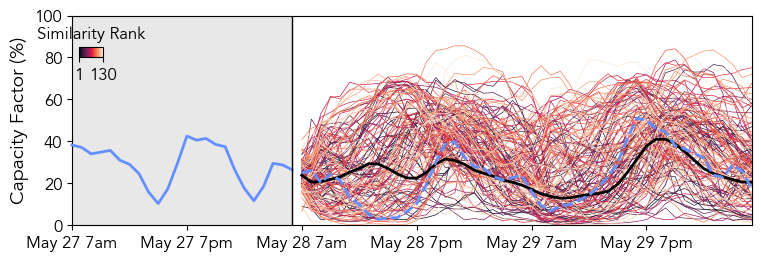

In [107]:
def _plot_updates(_fig, 
                  _ax, 
                  M_, 
                  f_, 
                  f_hat_, 
                  e_, 
                  w_, 
                  idx_, 
                  dx_, 
                  dt_, 
                  interval,
                  n = 720):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    z_   = (w_ - w_[idx_].min()) / (w_[idx_].max() - w_[idx_].min())
    
    w_selected_ = w_[idx_]
    
    idx_w_ = np.argsort(w_selected_)
    idx_   = idx_[idx_w_]
    
    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1)

    _ax.plot([], [], 
             lw = 0.75,
             label=r"$\hat{\mu}_i(s)$", 
             c="k")

    _ax.plot(tau_, 100. * f_,
             c=palette_.loc[0, "ibm"],
             zorder=10,
             #label="CF (ac)",
             clip_on=False,
             lw=2)

    _ax.plot(s_, 100. * f_hat_,
             c=palette_.loc[0, "ibm"],
             zorder=10,
             lw=2,
             clip_on=False,
             ls="--")

    _ax.plot(dt_, 100. * e_, 
             lw=2, 
             zorder=9, 
             #label="CF (fc)", 
             clip_on=False, 
             c="k")

    for i, j in zip(idx_, range(idx_.shape[0])):
        _ax.plot(dt_[interval:], 100 * M_[j, :],
                 #c=_cmap(_norm(z_[i])), 
                 c=_cmap(_norm(j/idx_.shape[0])), 
                 lw=0.5, 
                 zorder=8)
        
    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color="lightgray",
                     alpha=0.5,
                     zorder=1)

    _ax.axvline(dt_[interval - 1], 
                color="k", 
                lw=1.0, 
                #label="Event (update)", 
                zorder=11)


    idx_ = (dt_ % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt_[idx_], dx_[idx_], rotation=0)
    
    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    
    _ax.tick_params(axis="both", 
                    labelsize=12)

    cbar = _fig.colorbar(cm.ScalarMappable(_norm, _cmap),
                         cax=_ax.inset_axes([45, 80, 150, 5], transform=_ax.transData),
                         orientation="horizontal")

    cbar.set_ticks([0, 1], 
                   labels=[1, M_.shape[0]], 
                   size=12)
    
    #cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Similarity Rank", 
                      rotation=0, 
                      size=12)

_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

_plot_updates(_fig, 
              _ax, 
              M_, 
              f_, 
              f_hat_, 
              e_p_, 
              _fdu.w_, 
              _fdu.idx_spatial_, 
              dx_, 
              dt_, 
              24)

# _ax.legend(loc=(0.5, 0.8),
#            frameon=False, 
#            fontsize=12, 
#            ncol=1)

# plt.savefig(path_to_images + f"/dynamic_update_neighbors-{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

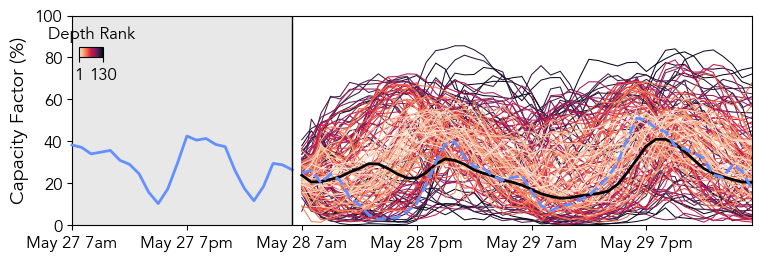

In [108]:
def _plot_depth(_fig, _ax, palette_, M_, f_, f_hat_, e_, w_, dx_, dt_, interval,
                n = 720,
                colorbar = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    idx_  = np.argsort(w_)
    _cmap = sns.color_palette("rocket", as_cmap=True)
    _norm = plt.Normalize(0., 1)

    _ax.plot([], [], 
             lw = 0.75,
             label = r"$\hat{\mu}_i(s)$", 
             c = "k")

    for i in range(idx_.shape[0]):
        _ax.plot(s_, 100 * M_[idx_[i], :],
                 c = _cmap(_norm(i/idx_.shape[0])), 
                 lw = 0.75, 
                 zorder = 0, 
                 clip_on = False)

    _ax.plot(dt_[:f_.shape[0]], 100 * f_,
             c = palette_.loc[0, "ibm"],
             #label = "CF (ac)",
             zorder = 9,
             lw = 2, 
             clip_on = False)

    _ax.plot(dt_[-f_hat_.shape[0]:], 100 * f_hat_,
             c = palette_.loc[0, "ibm"],
             zorder = 9,
             lw = 2,
             ls = "--", 
             clip_on = False)

    _ax.plot(dt_, 100 * e_, 
             lw = 2, 
             #label = "CF (fc)", 
             zorder = 8,
             c = "k", 
             clip_on = False)

    _ax.axvline(dt_[f_.shape[0] - 1], 
                color = "k", 
                lw = 1, 
                #label  = "Event (update)", 
                zorder = 10)
        
    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5,
                     zorder = 1)

    idx_ = (dt_ % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt_[idx_], dx_[idx_], rotation=0)
    
    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(_norm, sns.color_palette("rocket_r", as_cmap = True)),
                             cax = _ax.inset_axes([45, 80, 150, 5], transform = _ax.transData),
                             orientation = "horizontal")
    
        cbar.set_ticks([0, 1], 
                       labels = [1, M_.shape[0]], 
                       size = 12)
            
        cbar.ax.set_title("Depth Rank", 
                          rotation = 0, 
                          size = 12)


_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

depth = 'MBD'
depth_rank_ = _fDepth(_fdu.M_, depth, path_to_fDepth).to_numpy()[:, 0]

_plot_depth(_fig, 
            _ax, 
            palette_, 
            _fdu.M_, 
            f_, 
            f_hat_, 
            e_p_, 
            depth_rank_, 
            dx_, 
            dt_, 24,
            colorbar = True)

# _ax.legend(frameon = False, 
#            loc = (0.4, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.2,
#            ncol = 5)

# plt.savefig(path_to_images + f"/ranking-{depth}_{file_name}.pdf", 
#             bbox_inches = "tight")

plt.show()

(49,)


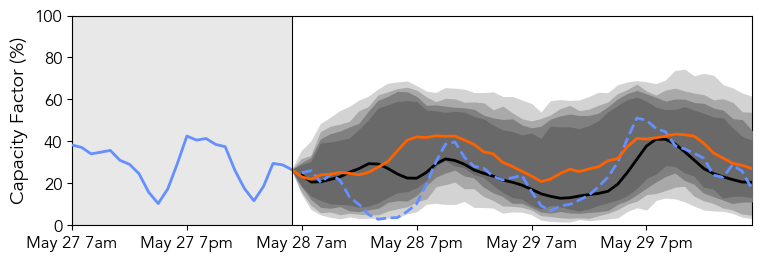

In [109]:
def _plot_envelop(_ax, _upper, _lower, m_, f_, f_hat_, e_, dt_, dx_, interval, 
                  n = 720,
                  color = palette_.loc[4, "ibm"],
                  label = r"$\bar{\mu} (s)$",
                  CR = 'CR',
                  legend_1 = True, 
                  legend_2 = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(dt_, 100*e_, 
             c = "k", 
             lw = 2, 
             clip_on = True,
             label = "CF (forecast)" if legend_1 else None, 
             zorder = 8)

    _ax.plot(tau_, 100*f_, 
             c = palette_.loc[0, "ibm"], 
             clip_on = True,
             label = "CF (actual)" if legend_1 else None, 
             lw = 2, 
             zorder = 9)
    
    _ax.plot(s_, 100*f_hat_, 
             clip_on = True,
             c = palette_.loc[0, "ibm"], 
             ls = "--", 
             lw = 2, 
             zorder = 9)

    _ax.plot(dt_[-m_.shape[0]:], 100*m_, 
             c = color, 
             label = label if legend_2 else None,
             lw = 2, 
             zorder = 10)
    
    colors_ = ["lightgray", "darkgray", "gray", "dimgray"]
    for color, key, i in zip(colors_, _upper.keys(), range(len(_upper.keys()))):
        u_ = _upper[key]
        l_ = _lower[key]

        cr = int((1. - float(key))*100)

        _ax.fill_between(dt_[-u_.shape[0]:], 100*u_, 100*l_,
                         color  = color,
                         label  = f"{cr}% {CR}" if legend_2 else None,
                         zorder = i + 1)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)

    _ax.axvline(dt_[interval - 1], 
                color = "k", 
                linewidth = 0.75, 
                #label = "Event (update)",
                zorder = 11)

    idx_ = (dt_ % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt_[idx_], dx_[idx_], rotation=0)
        
    _ax.tick_params(axis = "both", 
                    labelsize = 12)
    
    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size = 14)

# Calculate confidence intervals from Directional Quantiles
f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(_fdu.M_ext_, alpha_ = [0.1, 0.2, 0.3, 0.4])
print(f_median_ext_.shape)
_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

_plot_envelop(_ax, _upper, _lower, f_median_ext_, f_, f_hat_, e_p_, dt_, dx_, 24, 
              color = palette_.loc[3, "ibm"],
              CR = 'CI',
              label = r"$\bar{\mu} (s)$",
              legend_1 = False, 
              legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.25,
#            ncol = 5)

plt.show()

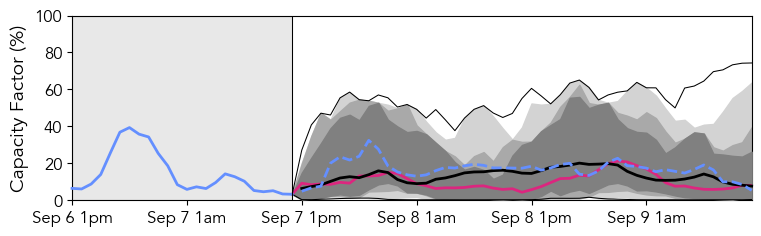

In [208]:
def _plot_enhanced_functional_boxplot(_ax, _upper, _lower, m_, f_, f_hat_, e_, dt_, dx_, interval,
                                      n = 720,
                                      legend_1 = True, 
                                      legend_2 = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    _ax.plot(dt_, 100 * e_, 
             c = "k", 
             lw = 2, 
             zorder = 8,
             #label = "CF (forecast)" if legend_1 else None
             clip_on = False)

    _ax.plot(tau_, 100 * f_, 
             c = palette_.loc[0, "ibm"], 
             #label = "CF (actual)" if legend_1 else None, 
             zorder = 9,
             lw = 2, 
             clip_on = False)

    _ax.plot(s_, 100 * f_hat_, 
             c  = palette_.loc[0, "ibm"], 
             lw = 2, 
             ls = "--", 
             zorder = 9,
             clip_on = False)
    #m_p_ = np.concatenate([f_[-1] * np.ones((1,)), m_], axis=0)

    _ax.plot(dt_[-m_.shape[0]:], 100 * m_, 
             c = palette_.loc[2, "ibm"], 
             ls = '-',
             zorder = 4,
             label = r"$\bar{\mu} (s)$" if legend_1 else None,
             lw = 2)
    
    u_ = _upper['max']
    l_ = _lower['min']

    _ax.plot(dt_[-u_.shape[0]:], 100 * u_, 
             c = 'k', 
             lw = .75, 
             zorder = 7)
    
    _ax.plot(dt_[-l_.shape[0]:], 100 * l_, 
             c = 'k', 
             lw = .75, 
             zorder = 7, 
             label = "min-max" if legend_2 else None)

    _upper.pop('max')
    _lower.pop('min')

    colors_ = ["lightgray", "darkgray", "gray"]

    for color, key, i in zip(colors_, _upper.keys(), range(len(_upper.keys()))):
        u_ = _upper[key]
        l_ = _lower[key]

        cr = int((1. - float(key)) * 100)
        
        _ax.fill_between(dt_[-u_.shape[0]:], 100 * u_, 100 * l_,
                         color = color,
                         label = f"{cr}% CR" if legend_2 else None,
                         zorder = i + 1)

    _ax.axvline(dt_[interval - 1], 
                color = "k", 
                linewidth = 0.75, 
                #label = "Event (update)",
                zorder = 10)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)
    
    _ax.tick_params(axis = "both", 
                    labelsize = 12)

    idx_ = (dt_ % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt_[idx_], dx_[idx_], rotation=0)
    
    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])
    _ax.set_ylabel("Capacity Factor (%)", size=14)


# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(_fdu.M_ext_, depth_rank_)

_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_enhanced_functional_boxplot(_ax, _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dt_, dx_, 24,
                                  legend_1 = False, 
                                  legend_2 = False)
    
# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.2,
#            ncol = 6)

# plt.savefig(path_to_images + f"/fboxplot-{depth}_{file_name}.pdf", 
#             bbox_inches = "tight")

plt.show()

[0.9 0.9 0.9 0.8]
45 (45, 48)
45 (45, 48)
45 (45, 48)
40 (40, 48)


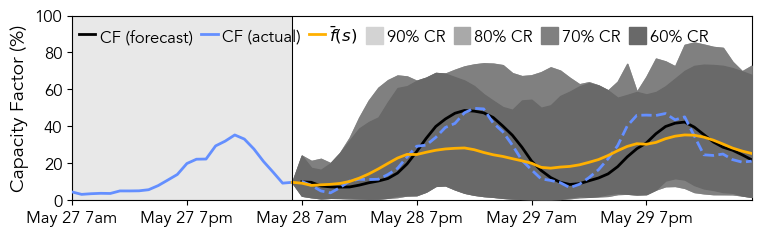

In [242]:
# Samples in each confidence band
depth = 'sup'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = IntegratedDepth()
_depth = ModifiedBandDepth()

k_ = _get_band_fraction(envelope_, alpha_, depth, interval)
print(k_)

J_ = _fdu.focal_curve_envelope(_depth, _fdu.M_ext_, depth, max_iter = 100)


f_focal_ext_, _upper, _lower = _fdu.focal_envelop_confidence_bands(alpha_, k_)

_fig, _ax = plt.subplots(figsize = (7.5, 2.25), constrained_layout = True)

_plot_envelop(_ax, _upper, _lower, f_focal_ext_, f_, f_hat_, e_p_, dt_, dx_, 24, 
              color = palette_.loc[4, "ibm"],
              label = r"$\bar{f} (s)$",
              CR = 'CR',
              legend_1 = True, 
              legend_2 = True)

_ax.legend(frameon = False, 
           loc = (0.0, .8),
           fontsize = 12,
           columnspacing=0.5,
           handletextpad=0.25,
           ncol = 7)

plt.savefig(path_to_images + f"/focal_curve_envelop-{file_name}.pdf", 
            bbox_inches = "tight")

plt.show()

[0.6  0.4  0.25 0.15]


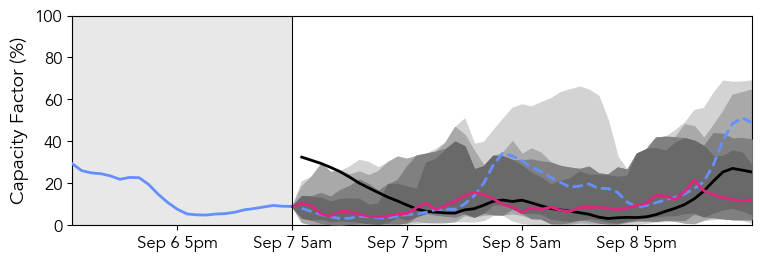

In [173]:
# Samples in each confidence band
depth = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]

k_ = _get_band_fraction(envelope_, alpha_, depth, interval)
print(k_)
f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(_depth, _fdu.M_ext_, alpha_, k_)

_fig, _ax = plt.subplots(figsize = (7.5, 2.5), constrained_layout = True)

_plot_envelop(_ax, _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dt_, dx_, 24, 
              CR = 'CR',
              label = r"$\tilde{f} (s)$",
              color = palette_.loc[2, "ibm"],
              legend_1 = False, 
              legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.1875, .825),
#            fontsize = 12,
#            columnspacing=0.5,
#            handletextpad=0.25,
#            ncol = 5)

# plt.savefig(path_to_images + f"/depth-{depth}_{file_name}.pdf", 
#             bbox_inches="tight")

plt.show()

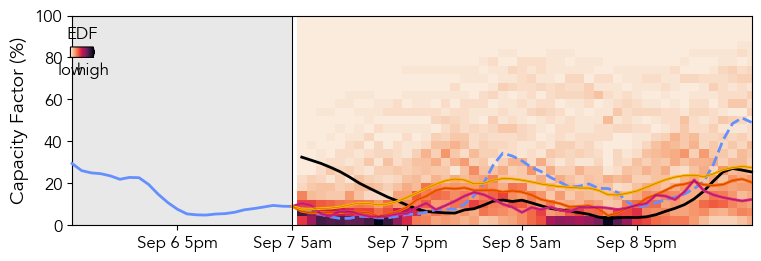

In [174]:
def _plot_density_heatmap(_fig, _ax, M_, f_median_, f_deepest_, f_focal_, f_, f_hat_, e_, dx_, dt_, interval, 
                          n = 720,
                          colorbar = True,
                          legend_1 = True,
                          legend_2 = True):

    tau_ = dt_[:interval]
    s_   = dt_[interval:]
    dt   = dt_[1] - dt_[0]

    Z_ = []
    for i in range(M_.shape[1]):
        a_, b_ = np.histogram(100 * M_[:, i], 
                              bins = 25, 
                              range = (0, 100), 
                              density = True)
        Z_.append(a_)

    Z_     = np.stack(Z_).T
    X_, Y_ = np.meshgrid(dt_[interval:], (b_[1:] + b_[:-1]) / 2.0)

    _cmap = sns.color_palette("rocket_r", as_cmap = True)
    _ax.pcolormesh(X_, Y_, Z_, cmap = _cmap, alpha = 1.)

    _ax.plot(dt_[-f_median_.shape[0]:], 100 * f_median_, 
             c = palette_.loc[3, "ibm"], 
             label = r"$\bar{\mu} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)

    _ax.plot(dt_[-f_median_.shape[0]:], 100 * f_median_, 
             c = 'k', 
             lw = .25,
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(dt_[-f_deepest_.shape[0]:], 100 * f_deepest_, 
             c = palette_.loc[2, "ibm"], 
             label = r"$\bar{f} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)
    
    _ax.plot(dt_[-f_deepest_.shape[0]:], 100 * f_deepest_, 
             c = 'k', 
             lw = .25, 
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(dt_[-f_focal_.shape[0]:], 100 * f_focal_, 
             c = palette_.loc[4, "ibm"], 
             label = r"$\tilde{f} (s)$" if legend_2 else None,
             lw = 2, 
             zorder = 10)

    _ax.plot(dt_[-f_focal_.shape[0]:], 100 * f_focal_, 
             c = 'k', 
             lw = .25, 
             alpha = 0.5,
             zorder = 11)
    
    _ax.plot(tau_, 100 * f_,
             c = palette_.loc[0, "ibm"],
             zorder = 9,
             lw = 2,
             label = "CF (actual)" if legend_1 else None, 
             clip_on = False)

    _ax.plot(s_, 100 * f_hat_, 
             c = palette_.loc[0, "ibm"], 
             zorder = 9,
             lw = 2, 
             ls = "--", 
             clip_on = False)

    _ax.plot(dt_, 100 * e_, 
             c = "k", 
             lw = 2, 
             label = "CF (forecast)" if legend_1 else None, 
             zorder = 8,
             clip_on = False)

    _ax.axvline(dt_[interval - 1], 
                color = "k", 
                linewidth = 0.75, 
                label = "Event (update)" if legend_1 else None,
                zorder = 10)

    _ax.fill_between(tau_, 100 * np.ones(tau_.shape), 100 * np.zeros(tau_.shape),
                     color = "lightgray",
                     alpha = 0.5)

    idx_ = (dt_ % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt_[idx_], dx_[idx_], rotation=0)
    
    _ax.set_ylabel("Capacity Factor (%)", size = 14)

    _ax.tick_params(axis = "both", labelsize = 12)

    _ax.set_ylim(0, 100)
    _ax.set_xlim(dt_[0], dt_[-1])

    if colorbar:
        cbar = _fig.colorbar(cm.ScalarMappable(cmap=_cmap),
                             cax = _ax.inset_axes([50, 80, 150, 5], transform=_ax.transData),
                             orientation = "horizontal",
                             extend = "max")
    
        cbar.set_ticks([0, 1], 
                       labels = ["low", "high"], 
                       fontsize = 12)
        
        cbar.ax.tick_params(length=0)
    
        cbar.ax.set_title("EDF", rotation=0)
    
_fig, _ax = plt.subplots(figsize = (7.5, 2.5), 
                         constrained_layout = True)

_plot_density_heatmap(_fig, _ax, _fdu.M_, _fdu.f_median_ext_, _fdu.f_deepest_ext_, _fdu.f_focal_ext_,
                      f_, f_hat_, e_p_, dx_, dt_, 24, 
                      colorbar = True,
                      legend_1 = False,
                      legend_2 = False)

# _ax.legend(frameon = False, 
#            loc = (0.0125, .8),
#            fontsize = 12, 
#            ncol = 3)

# plt.savefig(path_to_images + f"/heatmap-{file_name}.pdf", 
#             bbox_inches = "tight")

plt.show()